In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

In [2]:
tran=pd.read_excel('/Users/chungkaichou/PycharmProjects/pythonProject1/PortFolio/Forage/KPMG/Task1/KPMG_VI_New_raw_data_update_final.xlsx',sheet_name='Transactions',header=1)
cust_demo=pd.read_excel('/Users/chungkaichou/PycharmProjects/pythonProject1/PortFolio/Forage/KPMG/Task1/KPMG_VI_New_raw_data_update_final.xlsx',sheet_name='CustomerDemographic',header=1)
cust_add=pd.read_excel('/Users/chungkaichou/PycharmProjects/pythonProject1/PortFolio/Forage/KPMG/Task1/KPMG_VI_New_raw_data_update_final.xlsx',sheet_name='CustomerAddress',header=1)

/var/folders/dr/05g6dmcd47v9mvnt25smv94h0000gn/T/ipykernel_53816/219313958.py:2: FutureWarning: Inferring datetime64[ns] from data containing strings is deprecated and will be removed in a future version. To retain the old behavior explicitly pass Series(data, dtype=datetime64[ns])
  cust_demo=pd.read_excel('/Users/chungkaichou/PycharmProjects/pythonProject1/PortFolio/Forage/KPMG/Task1/KPMG_VI_New_raw_data_update_final.xlsx',sheet_name='CustomerDemographic',header=1)


In [3]:
tran.head()

,transaction_id,product_id,customer_id,transaction_date,online_order,order_status,brand,product_line,product_class,product_size,list_price,standard_cost,product_first_sold_date
0,1,2,2950,2017-02-25,0.0,Approved,Solex,Standard,medium,medium,71.49,53.62,41245.0
1,2,3,3120,2017-05-21,1.0,Approved,Trek Bicycles,Standard,medium,large,2091.47,388.92,41701.0
2,3,37,402,2017-10-16,0.0,Approved,OHM Cycles,Standard,low,medium,1793.43,248.82,36361.0
3,4,88,3135,2017-08-31,0.0,Approved,Norco Bicycles,Standard,medium,medium,1198.46,381.10,36145.0
4,5,78,787,2017-10-01,1.0,Approved,Giant Bicycles,Standard,medium,large,1765.30,709.48,42226.0


In [4]:
tran.shape

(20000, 13)

In [5]:
tran.describe()

,transaction_id,product_id,customer_id,online_order,list_price,standard_cost,product_first_sold_date
count,20000.000000,20000.00000,20000.000000,19640.000000,20000.000000,19803.000000,19803.000000
mean,10000.500000,45.36465,1738.246050,0.500458,1107.829449,556.046951,38199.776549
std,5773.647028,30.75359,1011.951046,0.500013,582.825242,405.955660,2875.201110
min,1.000000,0.00000,1.000000,0.000000,12.010000,7.210000,33259.000000
25%,5000.750000,18.00000,857.750000,0.000000,575.270000,215.140000,35667.000000
50%,10000.500000,44.00000,1736.000000,1.000000,1163.890000,507.580000,38216.000000
75%,15000.250000,72.00000,2613.000000,1.000000,1635.300000,795.100000,40672.000000
max,20000.000000,100.00000,5034.000000,1.000000,2091.470000,1759.850000,42710.000000


In [6]:
tran.dtypes

transaction_id                      int64
product_id                          int64
customer_id                         int64
transaction_date           datetime64[ns]
online_order                      float64
order_status                       object
brand                              object
product_line                       object
product_class                      object
product_size                       object
list_price                        float64
standard_cost                     float64
product_first_sold_date           float64
dtype: object

In [7]:
tran.nunique()

transaction_id             20000
product_id                   101
customer_id                 3494
transaction_date             364
online_order                   2
order_status                   2
brand                          6
product_line                   4
product_class                  3
product_size                   3
list_price                   296
standard_cost                103
product_first_sold_date      100
dtype: int64

In [8]:
tran.isnull().sum()

transaction_id               0
product_id                   0
customer_id                  0
transaction_date             0
online_order               360
order_status                 0
brand                      197
product_line               197
product_class              197
product_size               197
list_price                   0
standard_cost              197
product_first_sold_date    197
dtype: int64

In [9]:
tran.dropna(subset='online_order',inplace=True)
tran.dropna(subset='brand',inplace=True)

In [10]:
tran.isnull().sum()

transaction_id             0
product_id                 0
customer_id                0
transaction_date           0
online_order               0
order_status               0
brand                      0
product_line               0
product_class              0
product_size               0
list_price                 0
standard_cost              0
product_first_sold_date    0
dtype: int64

In [11]:
tran.shape

(19445, 13)

In [12]:
tran[tran.duplicated()].sum()

/var/folders/dr/05g6dmcd47v9mvnt25smv94h0000gn/T/ipykernel_53816/1390018173.py:1: FutureWarning: The default value of numeric_only in DataFrame.sum is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  tran[tran.duplicated()].sum()


transaction_id             0.0
product_id                 0.0
customer_id                0.0
online_order               0.0
order_status               0.0
brand                      0.0
product_line               0.0
product_class              0.0
product_size               0.0
list_price                 0.0
standard_cost              0.0
product_first_sold_date    0.0
dtype: float64

In [13]:
from datetime import datetime
def convert_to_datetime(num):
    dt = datetime.fromordinal(datetime(1900, 1, 1).toordinal() + num - 2)
    return dt

In [14]:
tran['product_first_sold_date']=tran['product_first_sold_date'].astype(int)
tran['product_first_sold_date']=tran['product_first_sold_date'].apply(convert_to_datetime)

In [15]:
tran['product_first_sold_date']

0       2012-12-02
1       2014-03-03
2       1999-07-20
3       1998-12-16
4       2015-08-10
           ...    
19995   2003-07-21
19996   1997-05-10
19997   2010-08-20
19998   2004-08-17
19999   1999-06-23
Name: product_first_sold_date, Length: 19445, dtype: datetime64[ns]

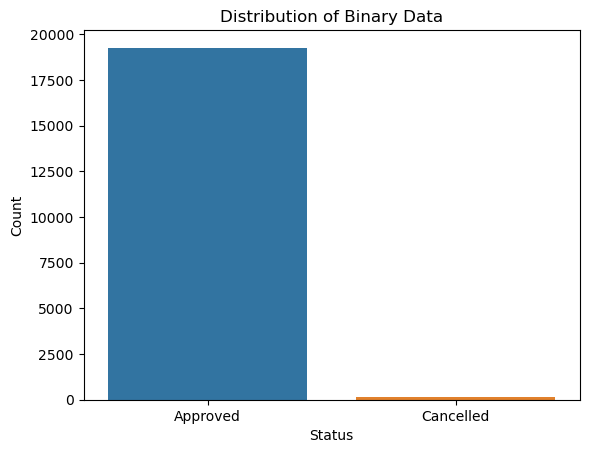

In [16]:
sb.countplot(x=tran['order_status'])
plt.xlabel("Status")
plt.ylabel("Count")
plt.title("Distribution of Binary Data")

# Show the plot
plt.show()

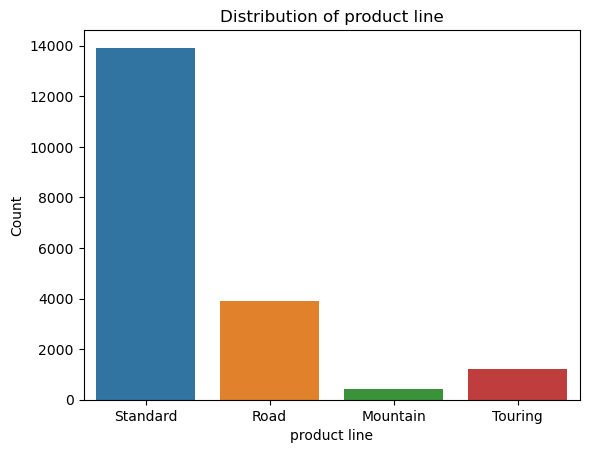

In [17]:
sb.countplot(x=tran['product_line'])
plt.xlabel("product line")
plt.ylabel("Count")
plt.title("Distribution of product line")

# Show the plot
plt.show()

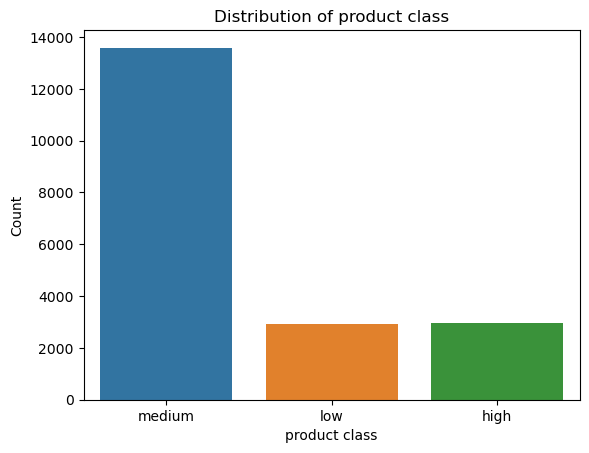

In [18]:
sb.countplot(x=tran['product_class'])
plt.xlabel("product class")
plt.ylabel("Count")
plt.title("Distribution of product class")

# Show the plot
plt.show()

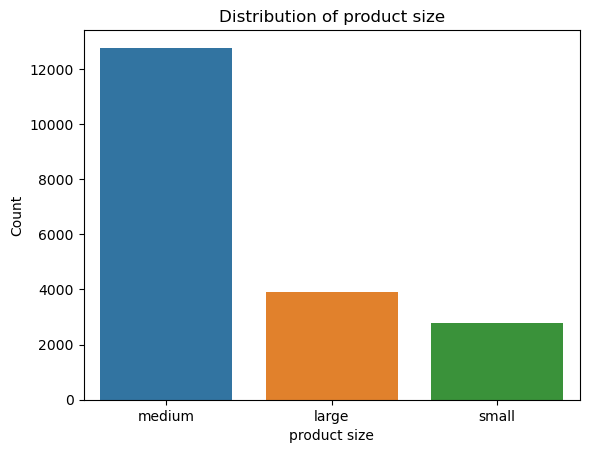

In [19]:
sb.countplot(x=tran['product_size'])
plt.xlabel("product size")
plt.ylabel("Count")
plt.title("Distribution of product size")

# Show the plot
plt.show()

<Axes: xlabel='online_order', ylabel='count'>

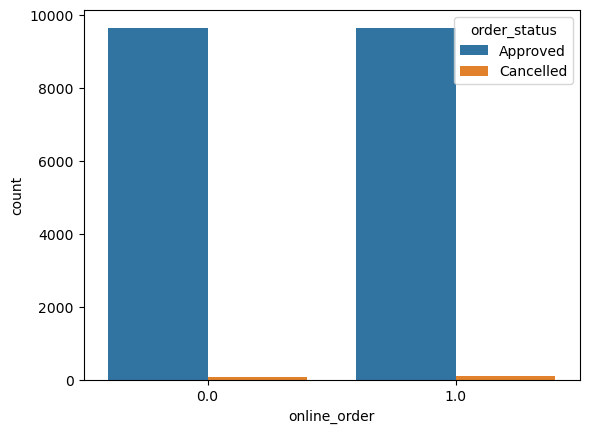

In [20]:
sb.countplot(data=tran,x='online_order',hue='order_status')

In [21]:
cust_demo.head()

,customer_id,first_name,last_name,gender,past_3_years_bike_related_purchases,DOB,job_title,job_industry_category,wealth_segment,deceased_indicator,default,owns_car,tenure
0,1,Laraine,Medendorp,F,93,1953-10-12,Executive Secretary,Health,Mass Customer,N,"""'",Yes,11.0
1,2,Eli,Bockman,Male,81,1980-12-16,Administrative Officer,Financial Services,Mass Customer,N,<script>alert('hi')</script>,Yes,16.0
2,3,Arlin,Dearle,Male,61,1954-01-20,Recruiting Manager,Property,Mass Customer,N,2018-02-01 00:00:00,Yes,15.0
3,4,Talbot,NaN,Male,33,1961-10-03,NaN,IT,Mass Customer,N,() { _; } >_[$($())] { touch /tmp/blns.shellsh...,No,7.0
4,5,Sheila-kathryn,Calton,Female,56,1977-05-13,Senior Editor,NaN,Affluent Customer,N,NIL,Yes,8.0


In [22]:
cust_demo.shape

(4000, 13)

In [23]:
cust_demo.describe()

,customer_id,past_3_years_bike_related_purchases,tenure
count,4000.000000,4000.000000,3913.000000
mean,2000.500000,48.890000,10.657041
std,1154.844867,28.715005,5.660146
min,1.000000,0.000000,1.000000
25%,1000.750000,24.000000,6.000000
50%,2000.500000,48.000000,11.000000
75%,3000.250000,73.000000,15.000000
max,4000.000000,99.000000,22.000000


In [24]:
cust_demo.dtypes

customer_id                                     int64
first_name                                     object
last_name                                      object
gender                                         object
past_3_years_bike_related_purchases             int64
DOB                                    datetime64[ns]
job_title                                      object
job_industry_category                          object
wealth_segment                                 object
deceased_indicator                             object
default                                        object
owns_car                                       object
tenure                                        float64
dtype: object

In [25]:
cust_demo[cust_demo.duplicated()].sum()

/var/folders/dr/05g6dmcd47v9mvnt25smv94h0000gn/T/ipykernel_53816/3641588598.py:1: FutureWarning: The default value of numeric_only in DataFrame.sum is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  cust_demo[cust_demo.duplicated()].sum()


customer_id                            0.0
first_name                             0.0
last_name                              0.0
gender                                 0.0
past_3_years_bike_related_purchases    0.0
job_title                              0.0
job_industry_category                  0.0
wealth_segment                         0.0
deceased_indicator                     0.0
default                                0.0
owns_car                               0.0
tenure                                 0.0
dtype: float64

In [26]:
cust_demo.isnull().sum()

customer_id                              0
first_name                               0
last_name                              125
gender                                   0
past_3_years_bike_related_purchases      0
DOB                                     87
job_title                              506
job_industry_category                  656
wealth_segment                           0
deceased_indicator                       0
default                                302
owns_car                                 0
tenure                                  87
dtype: int64

In [27]:
cust_demo.drop(columns='default',inplace=True)

In [28]:
median=cust_demo['tenure'].median()
median

11.0

In [29]:
cust_demo['tenure'].value_counts()

7.0     235
5.0     228
11.0    221
10.0    218
16.0    215
8.0     211
18.0    208
12.0    202
9.0     200
14.0    200
6.0     192
13.0    191
4.0     191
17.0    182
15.0    179
1.0     166
3.0     160
19.0    159
2.0     150
20.0     96
22.0     55
21.0     54
Name: tenure, dtype: int64

In [30]:
cust_demo['tenure'].fillna(median,inplace=True)

In [31]:
cust_demo.dropna(subset='DOB',inplace=True)

In [32]:
cust_demo['gender'].value_counts()

Female    2037
Male      1872
F            1
U            1
Femal        1
M            1
Name: gender, dtype: int64

In [33]:
cust_demo['gender'].replace({'F':'Female','Femal':'Female','M':'Male'},inplace=True)

In [34]:
cust_demo=cust_demo[cust_demo['gender']!='U']

In [35]:
cust_demo['job_industry_category'].value_counts()

Manufacturing         796
Financial Services    767
Health                596
Retail                358
Property              267
IT                    151
Entertainment         136
Argiculture           113
Telecommunications     72
Name: job_industry_category, dtype: int64

In [36]:
gender_counts=cust_demo['gender'].value_counts()

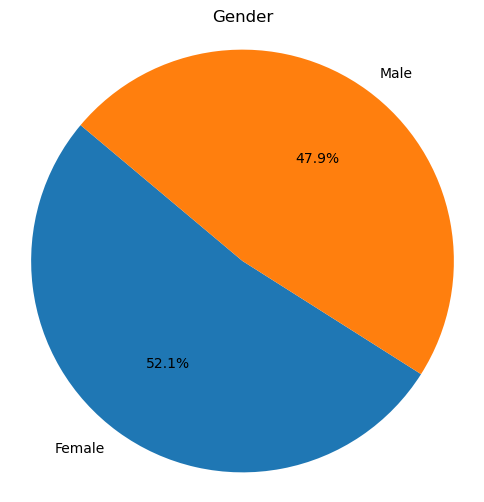

In [37]:
plt.figure(figsize=(6, 6))  # Adjust the figure size as needed
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Gender')

# Show the pie chart
plt.axis('equal')  # Equal aspect ratio ensures that the pie chart is circular
plt.show()

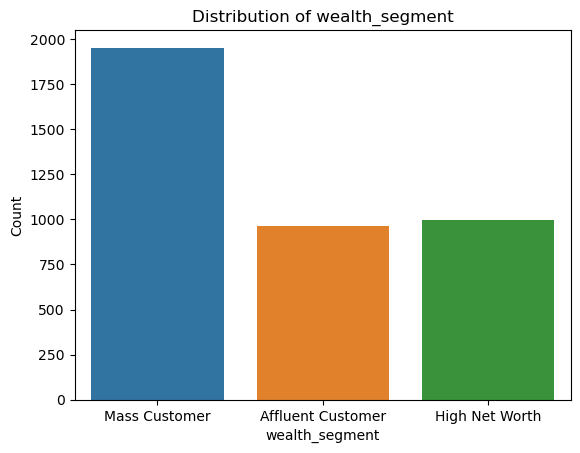

In [38]:
sb.countplot(x=cust_demo['wealth_segment'])
plt.xlabel("wealth_segment")
plt.ylabel("Count")
plt.title("Distribution of wealth_segment")

# Show the plot
plt.show()

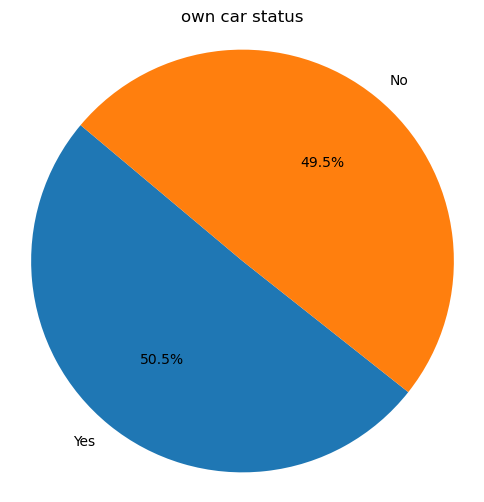

In [39]:
own_car=cust_demo['owns_car'].value_counts()
plt.figure(figsize=(6, 6))  # Adjust the figure size as needed
plt.pie(own_car, labels=own_car.index, autopct='%1.1f%%', startangle=140)
plt.title('own car status')

# Show the pie chart
plt.axis('equal')  # Equal aspect ratio ensures that the pie chart is circular
plt.show()

In [40]:
cust_add.head()

,customer_id,address,postcode,state,country,property_valuation
0,1,060 Morning Avenue,2016,New South Wales,Australia,10
1,2,6 Meadow Vale Court,2153,New South Wales,Australia,10
2,4,0 Holy Cross Court,4211,QLD,Australia,9
3,5,17979 Del Mar Point,2448,New South Wales,Australia,4
4,6,9 Oakridge Court,3216,VIC,Australia,9


In [41]:
cust_add.shape

(3999, 6)

In [42]:
cust_add.describe()

,customer_id,postcode,property_valuation
count,3999.000000,3999.000000,3999.000000
mean,2003.987997,2985.755939,7.514379
std,1154.576912,844.878364,2.824663
min,1.000000,2000.000000,1.000000
25%,1004.500000,2200.000000,6.000000
50%,2004.000000,2768.000000,8.000000
75%,3003.500000,3750.000000,10.000000
max,4003.000000,4883.000000,12.000000


In [43]:
cust_add.dtypes

customer_id            int64
address               object
postcode               int64
state                 object
country               object
property_valuation     int64
dtype: object

In [44]:
cust_add[cust_add.duplicated()].sum()

customer_id           0.0
address               0.0
postcode              0.0
state                 0.0
country               0.0
property_valuation    0.0
dtype: float64

In [45]:
cust_add.isnull().sum()

customer_id           0
address               0
postcode              0
state                 0
country               0
property_valuation    0
dtype: int64

In [46]:
cust_add['country'].value_counts()

Australia    3999
Name: country, dtype: int64

In [47]:
cust_add['state'].value_counts()

NSW                2054
VIC                 939
QLD                 838
New South Wales      86
Victoria             82
Name: state, dtype: int64

In [48]:
cust_add['state'].replace({'New South Wales':'NSW','Victoria':'VIC'},inplace=True)

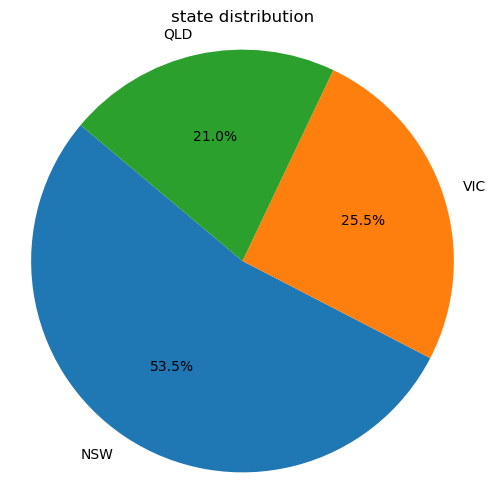

In [49]:
state_dis=cust_add['state'].value_counts()
plt.figure(figsize=(6, 6))  # Adjust the figure size as needed
plt.pie(state_dis, labels=state_dis.index, autopct='%1.1f%%', startangle=140)
plt.title('state distribution')

# Show the pie chart
plt.axis('equal')  # Equal aspect ratio ensures that the pie chart is circular
plt.show()

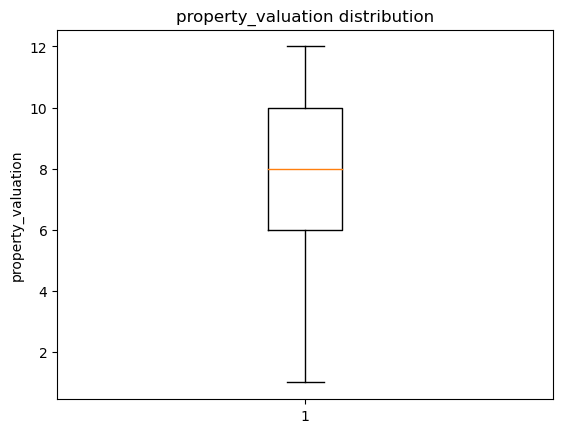

In [50]:
plt.boxplot(cust_add['property_valuation'])
plt.title('property_valuation distribution')
plt.ylabel('property_valuation')
plt.show()

In [51]:
cust_add.drop(columns=['address','postcode','country'],inplace=True)

In [52]:
mer_df=pd.merge(cust_demo,cust_add,on='customer_id',how='outer')
mer_df=pd.merge(mer_df,tran,on='customer_id',how='outer')

In [53]:
tran_counts=mer_df.groupby('customer_id')['customer_id'].transform('count')
mer_df['tran_counts']=tran_counts

In [54]:
def tran_dob_age(dob):
    date_birth=pd.to_datetime(dob)
    now=pd.Timestamp('now')
    age=now-date_birth
    return age

In [55]:
mer_df['age']=mer_df['DOB'].apply(tran_dob_age)
mer_df['age']=mer_df['age'].astype('<m8[Y]')

In [56]:
mer_df['age']

0        69.0
1        69.0
2        69.0
3        69.0
4        69.0
         ... 
19952     NaN
19953     NaN
19954     NaN
19955     NaN
19956     NaN
Name: age, Length: 19957, dtype: float64

In [108]:
def age_grouping(age):
    age_group=0
    if age<=35:
        age_group='Young Adults'
    elif age>35 and age<=60:
        age_group='Adults'
    else:
        age_group='Senior Adults'
    return age_group

In [109]:
mer_df['age_group']=mer_df['age'].apply(age_grouping)

In [57]:
mer_df.drop(columns=['first_name','last_name','DOB','job_title','transaction_id','product_id','transaction_date','product_first_sold_date'],inplace=True)

In [58]:
mer_df.isnull().sum()

customer_id                               0
gender                                  455
past_3_years_bike_related_purchases     455
job_industry_category                  3685
wealth_segment                          455
deceased_indicator                      455
owns_car                                455
tenure                                  455
state                                    29
property_valuation                       29
online_order                            512
order_status                            512
brand                                   512
product_line                            512
product_class                           512
product_size                            512
list_price                              512
standard_cost                           512
tran_counts                               0
age                                     455
dtype: int64

In [59]:
mer_df['job_industry_category'].fillna(mer_df['job_industry_category'].mode()[0],inplace=True)
mer_df['state'].fillna(mer_df['state'].mode()[0],inplace=True)
mer_df.dropna(inplace=True)

In [60]:
mer_df['profit']=mer_df['list_price']-mer_df['standard_cost']

In [110]:
mer_df.to_csv(r'/Users/chungkaichou/PycharmProjects/pythonProject1/PortFolio/Forage/KPMG/Task1/merge_df1.csv')

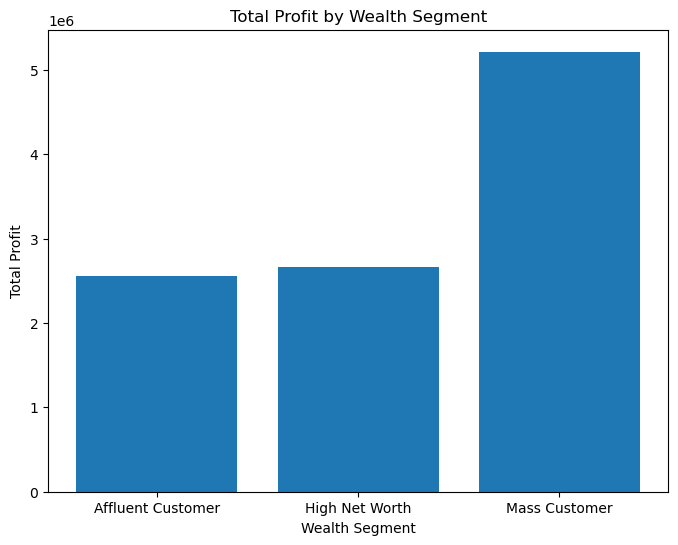

In [62]:
profit_for_wealth=mer_df.groupby('wealth_segment')['profit'].sum().reset_index()
plt.figure(figsize=(8, 6))
plt.bar(profit_for_wealth['wealth_segment'], profit_for_wealth['profit'])
plt.xlabel('Wealth Segment')
plt.ylabel('Total Profit')
plt.title('Total Profit by Wealth Segment')
plt.show()

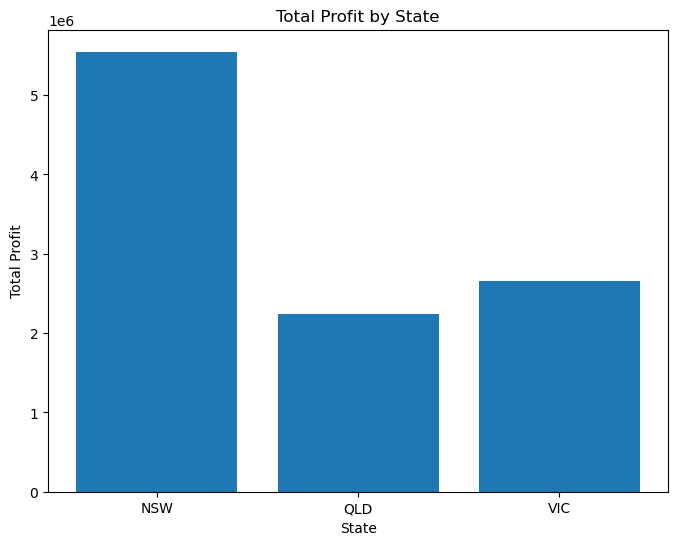

In [63]:
profit_for_state=mer_df.groupby('state')['profit'].sum().reset_index()
plt.figure(figsize=(8, 6))
plt.bar(profit_for_state['state'], profit_for_state['profit'])
plt.xlabel('State')
plt.ylabel('Total Profit')
plt.title('Total Profit by State')
plt.show()

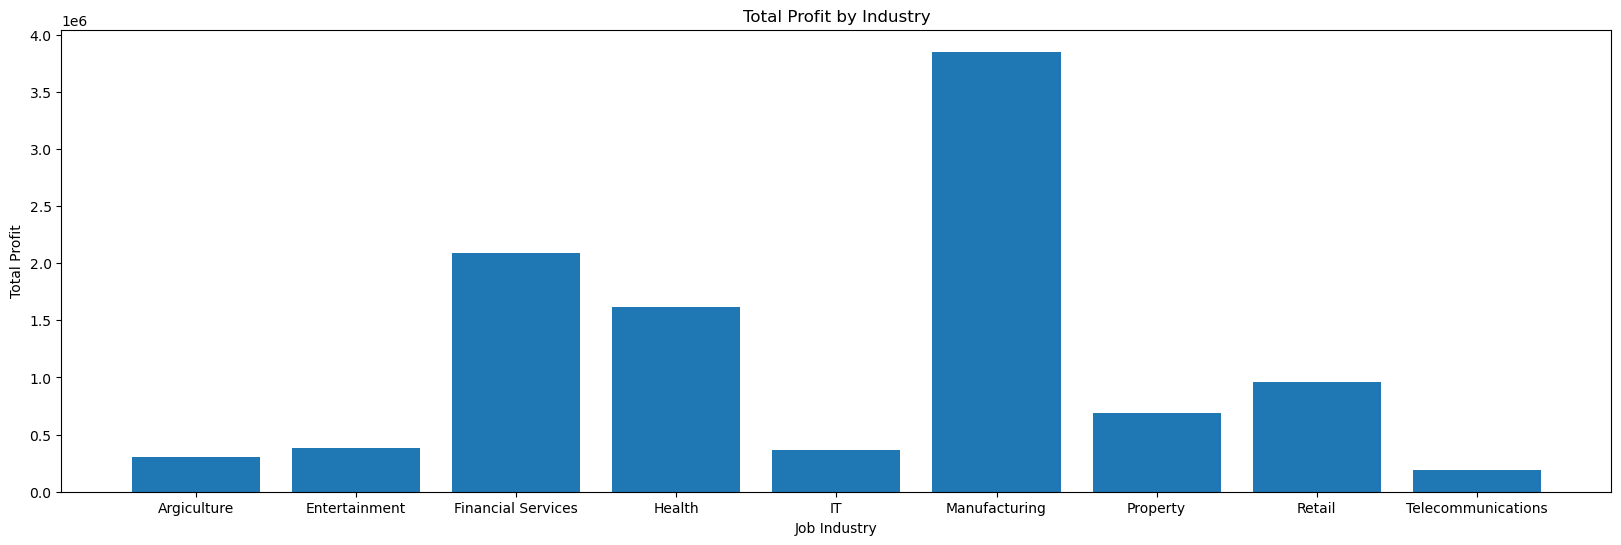

In [64]:
profit_for_industry=mer_df.groupby('job_industry_category')['profit'].sum().reset_index()
plt.figure(figsize=(20, 6))
plt.bar(profit_for_industry['job_industry_category'], profit_for_industry['profit'])
plt.xlabel('Job Industry')
plt.ylabel('Total Profit')
plt.title('Total Profit by Industry')
plt.show()

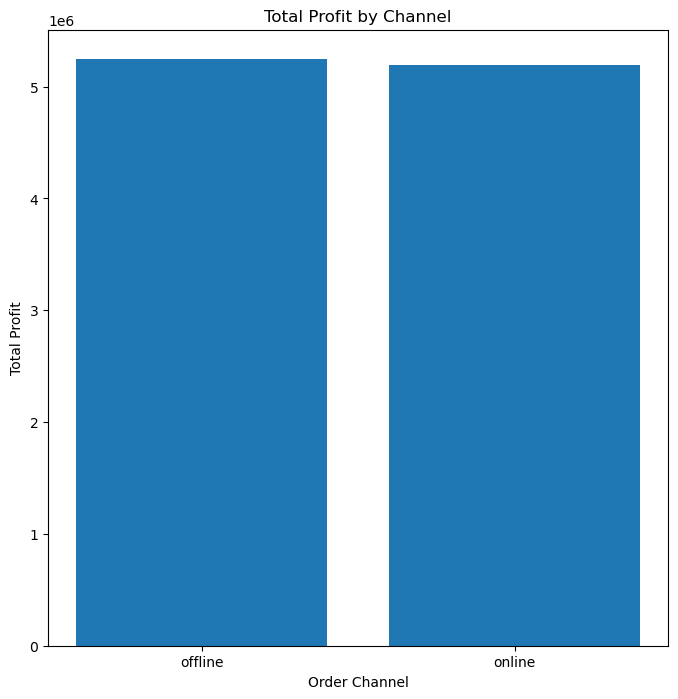

In [65]:
profit_for_channel=mer_df.groupby('online_order')['profit'].sum().reset_index()
plt.figure(figsize=(8, 8))
plt.bar(['offline','online'], profit_for_channel['profit'])
plt.xlabel('Order Channel')
plt.ylabel('Total Profit')
plt.title('Total Profit by Channel')
plt.show()

In [66]:
mer_df['brand'].value_counts()

Solex             4088
Giant Bicycles    3170
WeareA2B          3153
OHM Cycles        2927
Trek Bicycles     2857
Norco Bicycles    2783
Name: brand, dtype: int64

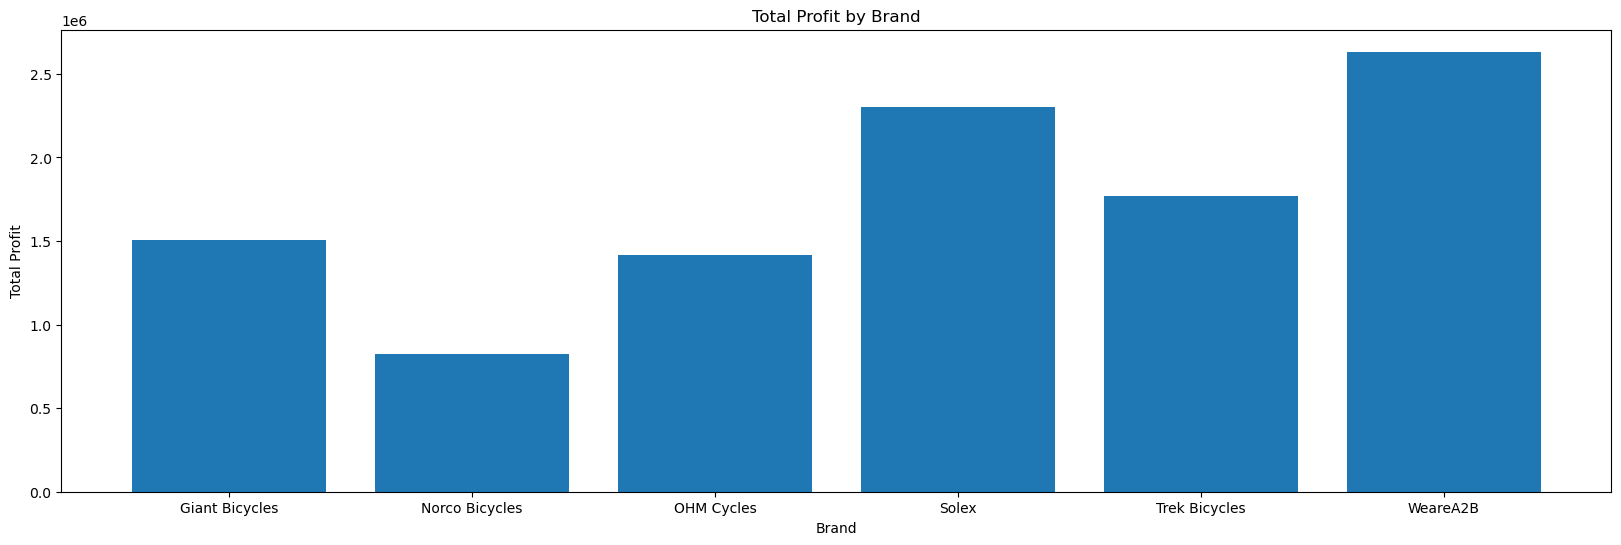

In [67]:
profit_for_brand=mer_df.groupby('brand')['profit'].sum().reset_index()
plt.figure(figsize=(20, 6))
plt.bar(profit_for_brand['brand'], profit_for_brand['profit'])
plt.xlabel('Brand')
plt.ylabel('Total Profit')
plt.title('Total Profit by Brand')
plt.show()

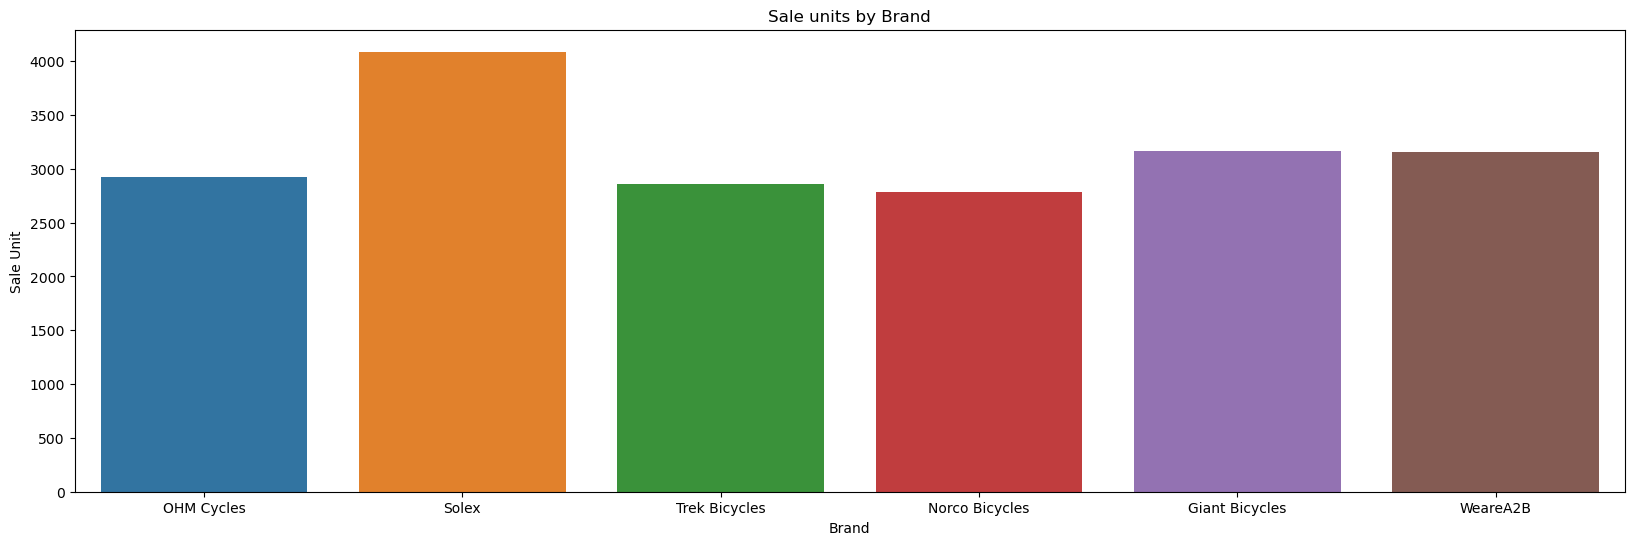

In [68]:
plt.figure(figsize=(20, 6))
sb.countplot(x=mer_df['brand'])
plt.xlabel('Brand')
plt.ylabel('Sale Unit')
plt.title('Sale units by Brand')
plt.show()

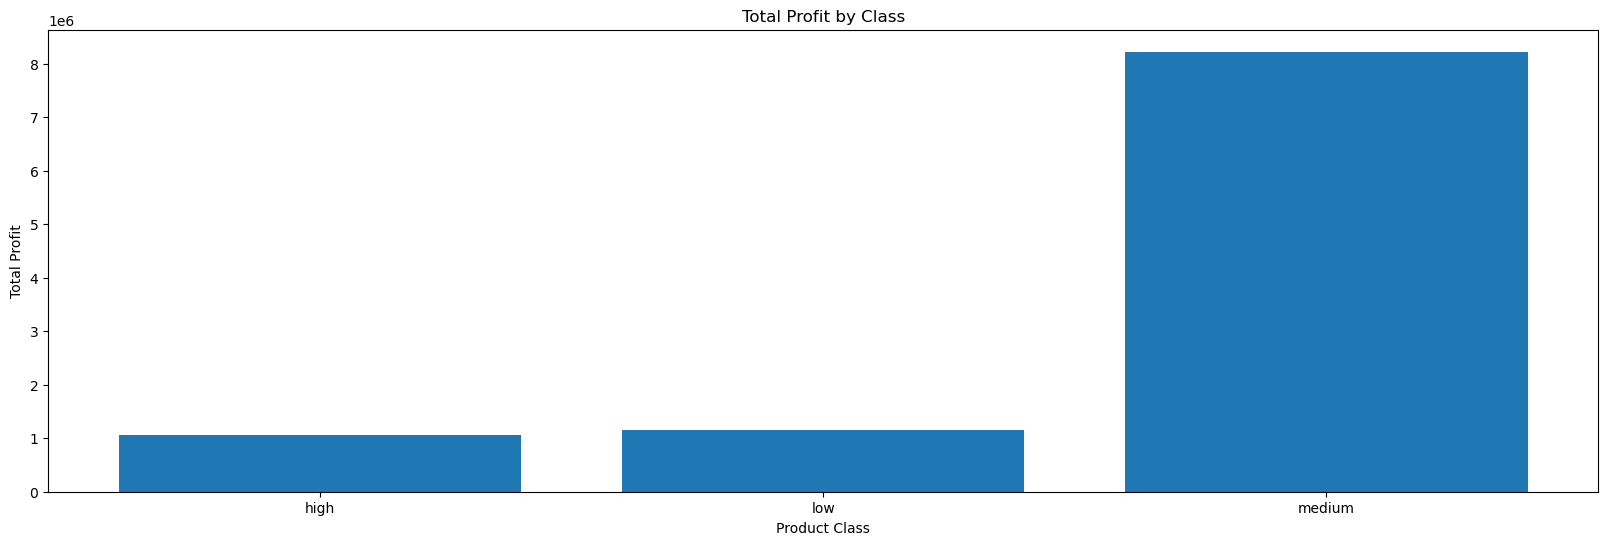

In [69]:
profit_for_class=mer_df.groupby('product_class')['profit'].sum().reset_index()
plt.figure(figsize=(20, 6))
plt.bar(profit_for_class['product_class'], profit_for_class['profit'])
plt.xlabel('Product Class')
plt.ylabel('Total Profit')
plt.title('Total Profit by Class')
plt.show()

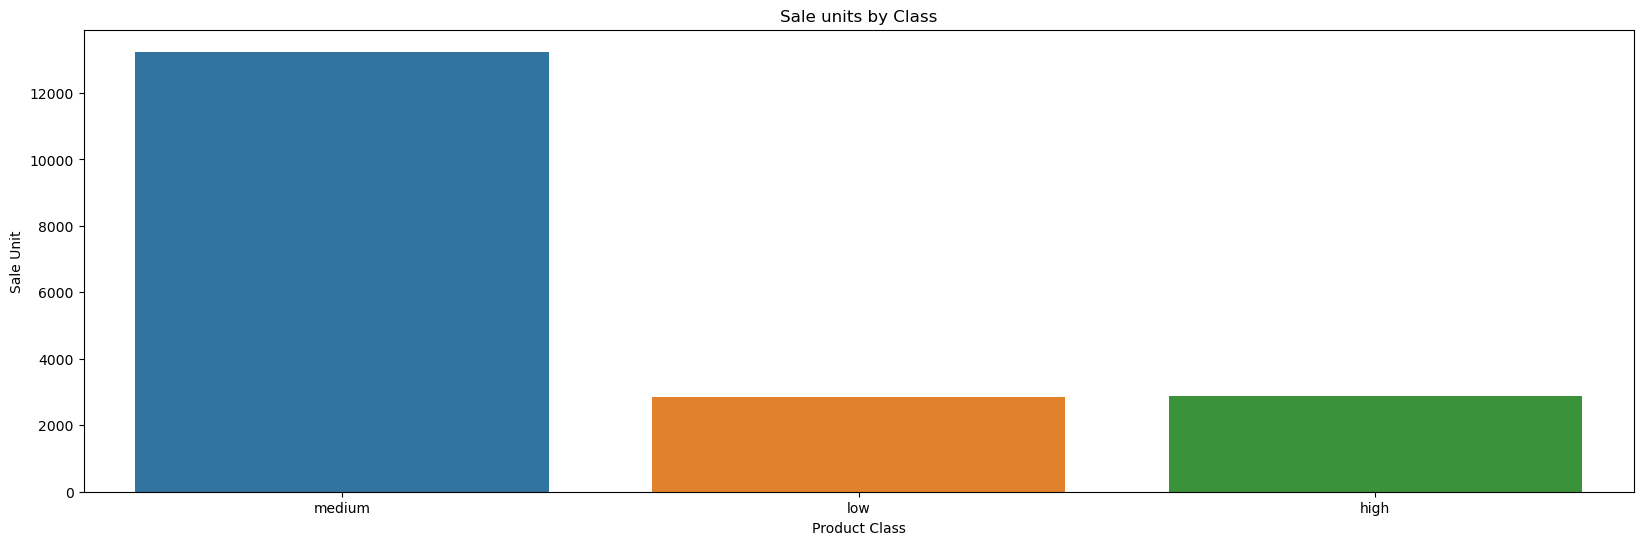

In [70]:
plt.figure(figsize=(20, 6))
sb.countplot(x=mer_df['product_class'])
plt.xlabel('Product Class')
plt.ylabel('Sale Unit')
plt.title('Sale units by Class')
plt.show()

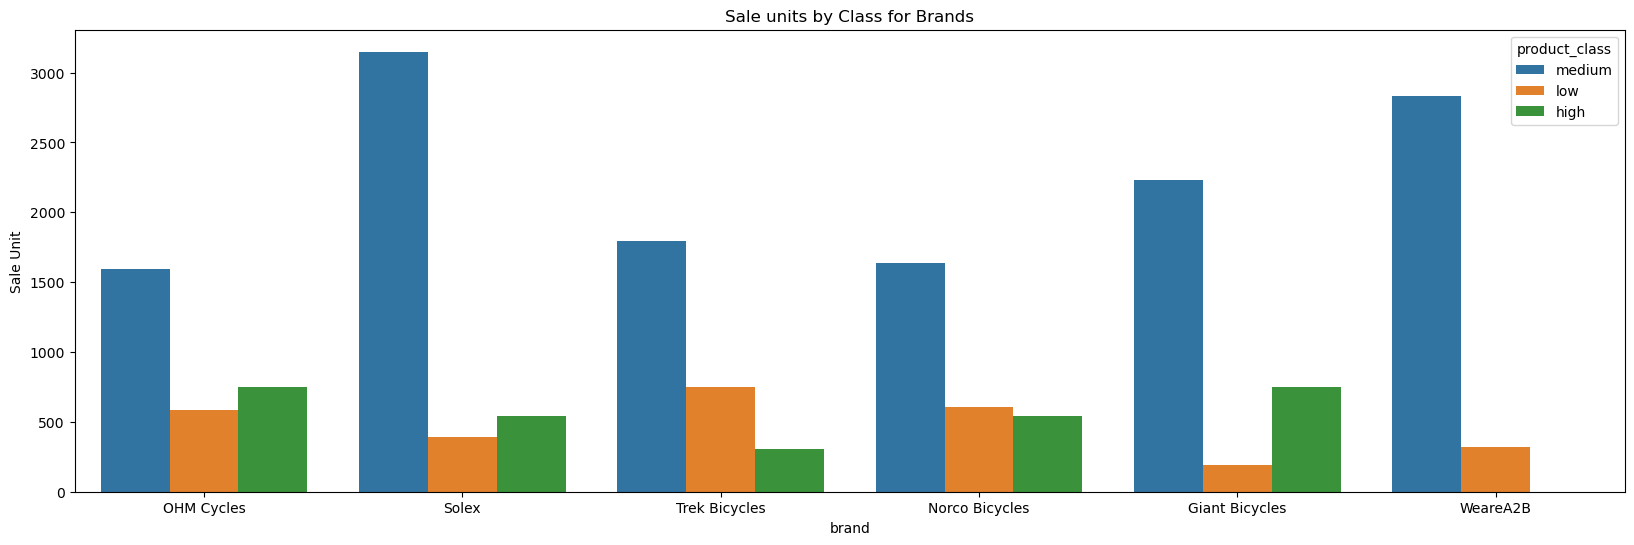

In [71]:
plt.figure(figsize=(20, 6))
sb.countplot(data=mer_df,x='brand',hue='product_class')
plt.ylabel('Sale Unit')
plt.title('Sale units by Class for Brands')
plt.show()

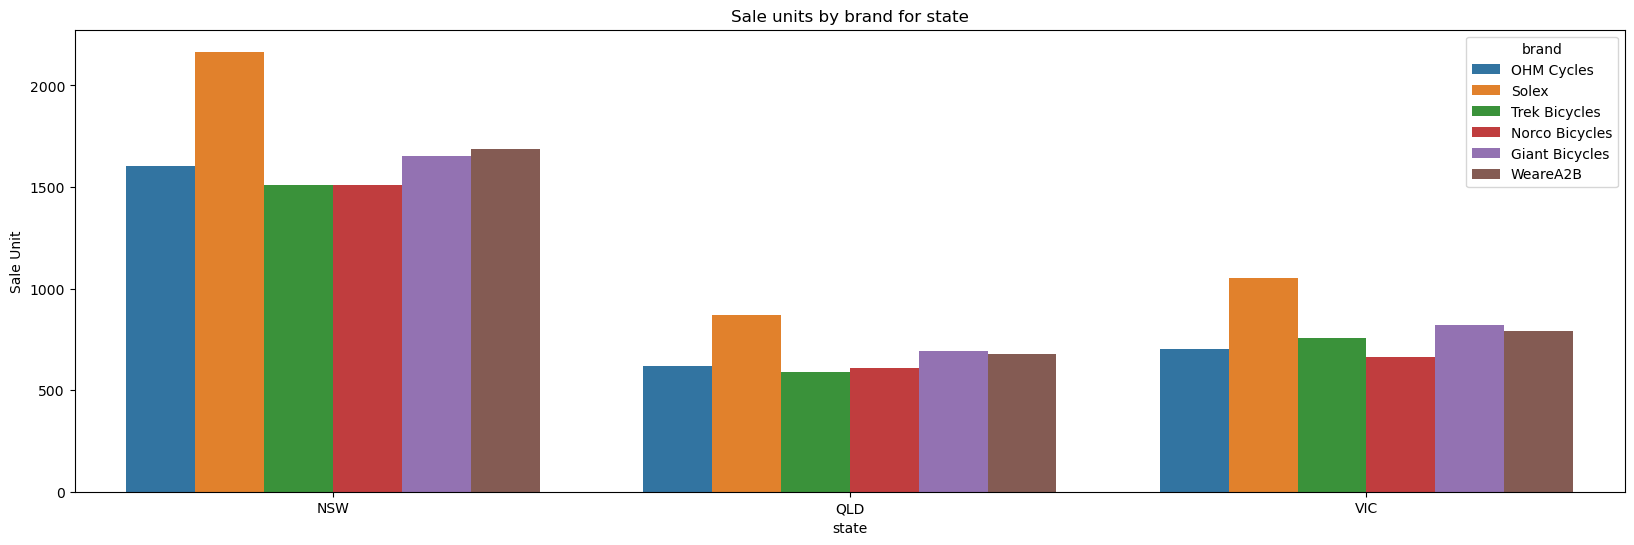

In [72]:
plt.figure(figsize=(20, 6))
sb.countplot(data=mer_df,x='state',hue='brand')
plt.ylabel('Sale Unit')
plt.title('Sale units by brand for state')
plt.show()

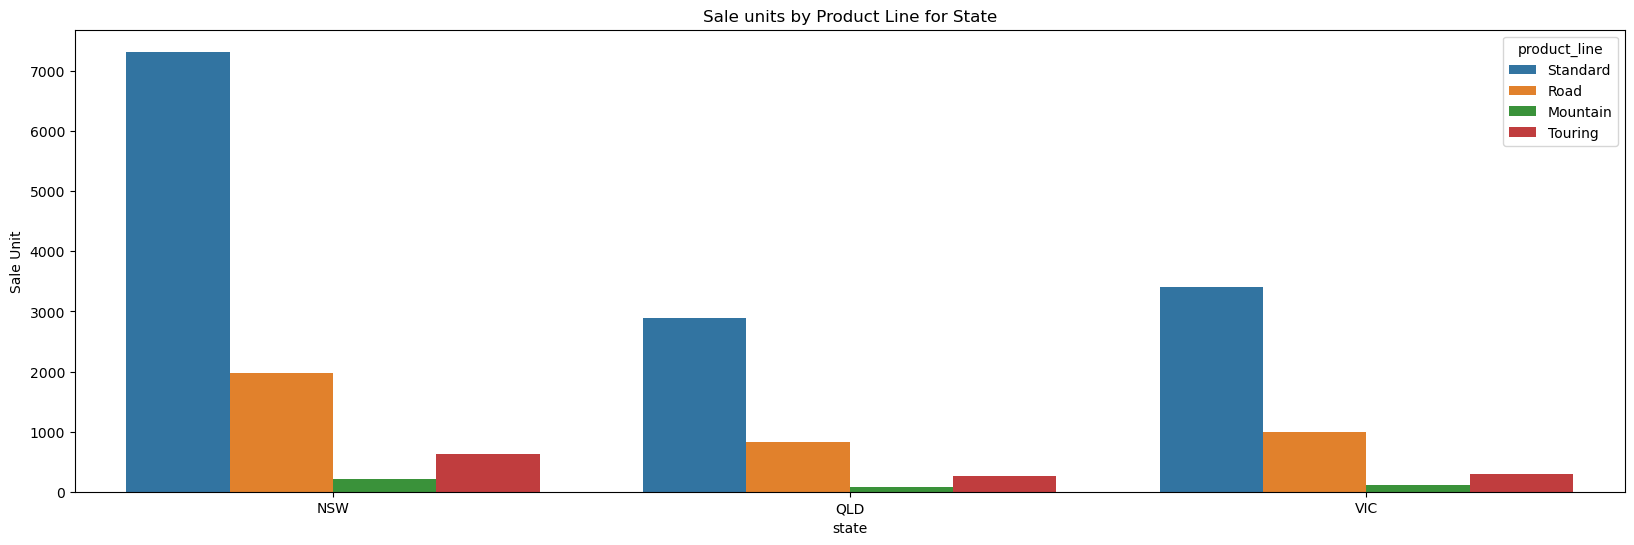

In [73]:
plt.figure(figsize=(20, 6))
sb.countplot(data=mer_df,x='state',hue='product_line')
plt.ylabel('Sale Unit')
plt.title('Sale units by Product Line for State')
plt.show()

{'whiskers': [<matplotlib.lines.Line2D at 0x15bf6a6d0>,
 'caps': [<matplotlib.lines.Line2D at 0x15d292a10>,
 'boxes': [<matplotlib.lines.Line2D at 0x15bf68650>],
 'medians': [<matplotlib.lines.Line2D at 0x15d293690>],
 'fliers': [<matplotlib.lines.Line2D at 0x15d2901d0>],
 'means': []}

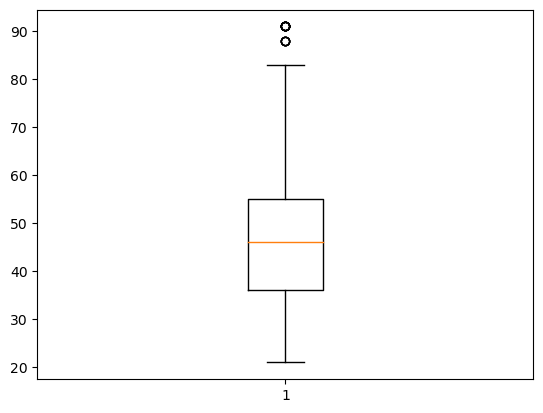

In [74]:
plt.boxplot(mer_df['age'])

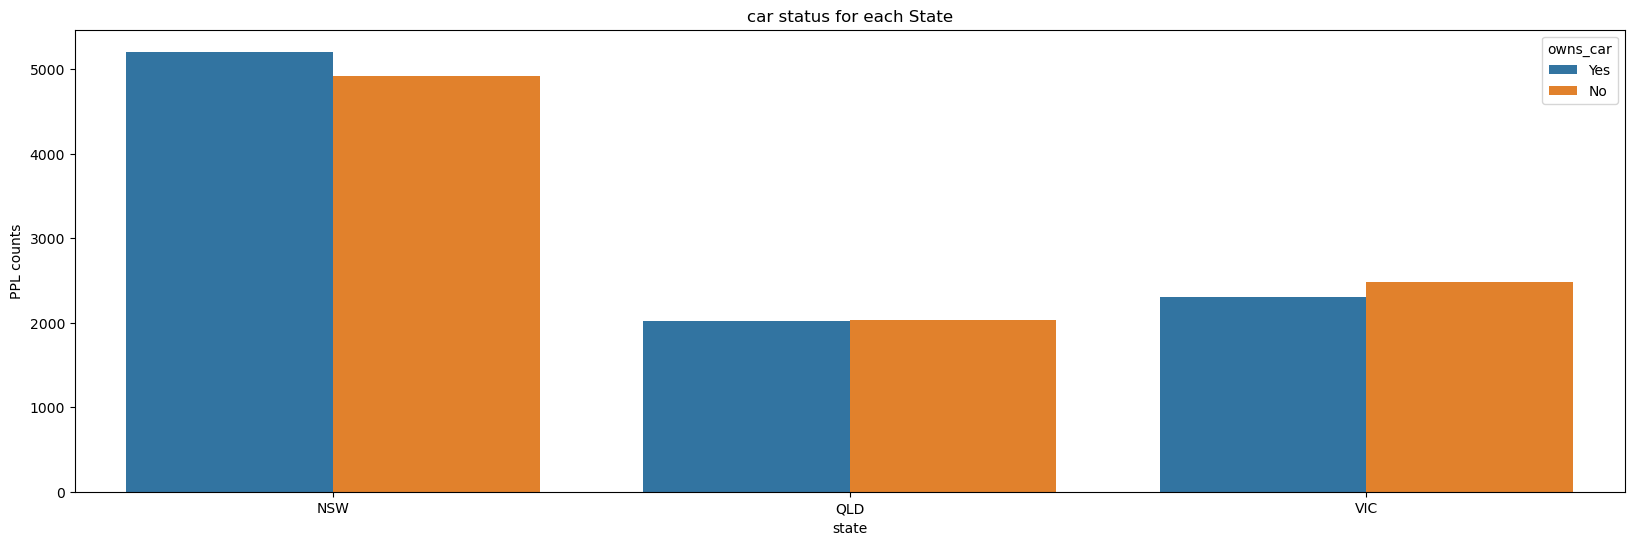

In [75]:
plt.figure(figsize=(20, 6))
sb.countplot(data=mer_df,x='state',hue='owns_car')
plt.ylabel('PPL counts')
plt.title('car status for each State')
plt.show()

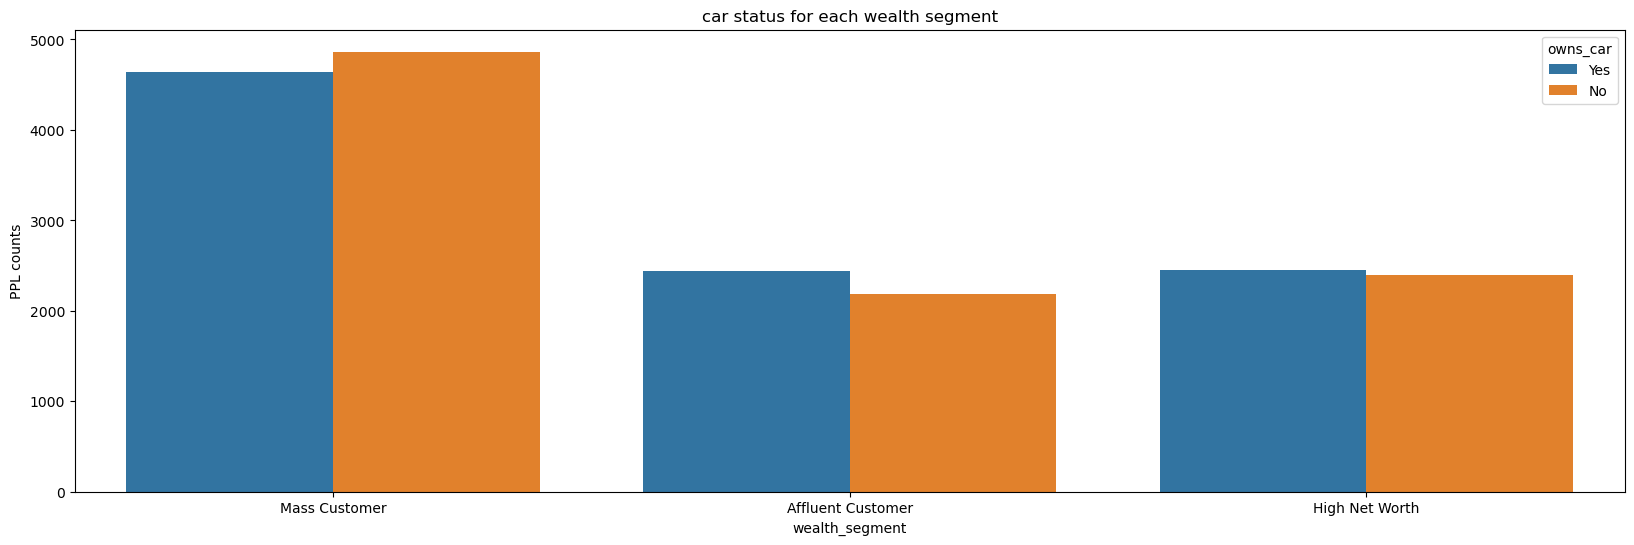

In [76]:
plt.figure(figsize=(20, 6))
sb.countplot(data=mer_df,x='wealth_segment',hue='owns_car')
plt.ylabel('PPL counts')
plt.title('car status for each wealth segment')
plt.show()

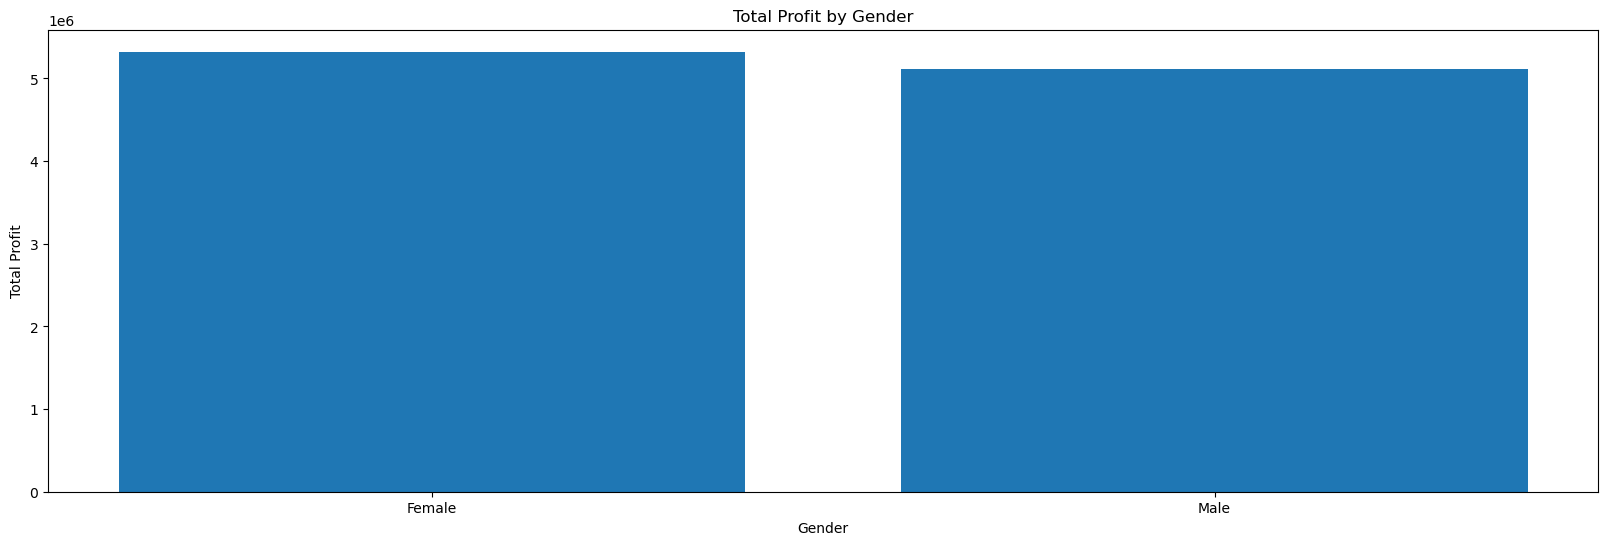

In [77]:
profit_for_gender=mer_df.groupby('gender')['profit'].sum().reset_index()
plt.figure(figsize=(20, 6))
plt.bar(profit_for_gender['gender'], profit_for_gender['profit'])
plt.xlabel('Gender')
plt.ylabel('Total Profit')
plt.title('Total Profit by Gender')
plt.show()

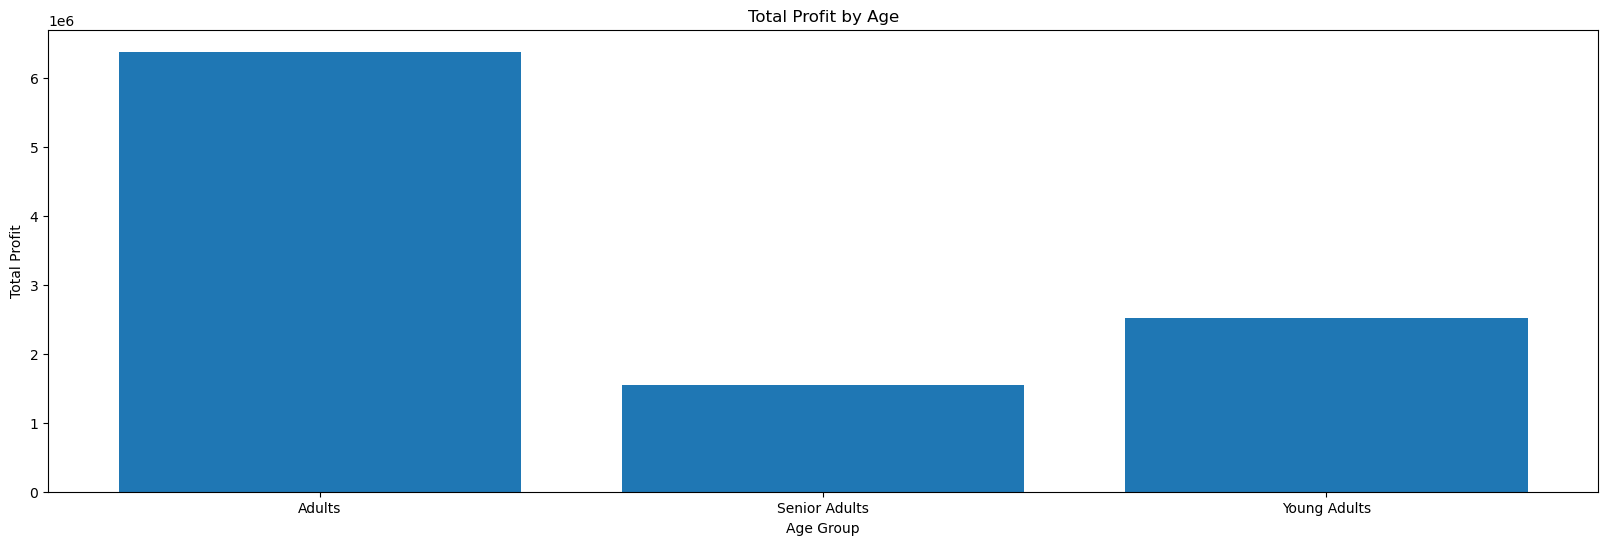

In [111]:
profit_for_age=mer_df.groupby('age_group')['profit'].sum().reset_index()
plt.figure(figsize=(20, 6))
plt.bar(profit_for_age['age_group'], profit_for_age['profit'])
plt.xlabel('Age Group')
plt.ylabel('Total Profit')
plt.title('Total Profit by Age')
plt.show()

/var/folders/dr/05g6dmcd47v9mvnt25smv94h0000gn/T/ipykernel_53816/1836341814.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sb.heatmap(data=mer_df.corr())


<Axes: >

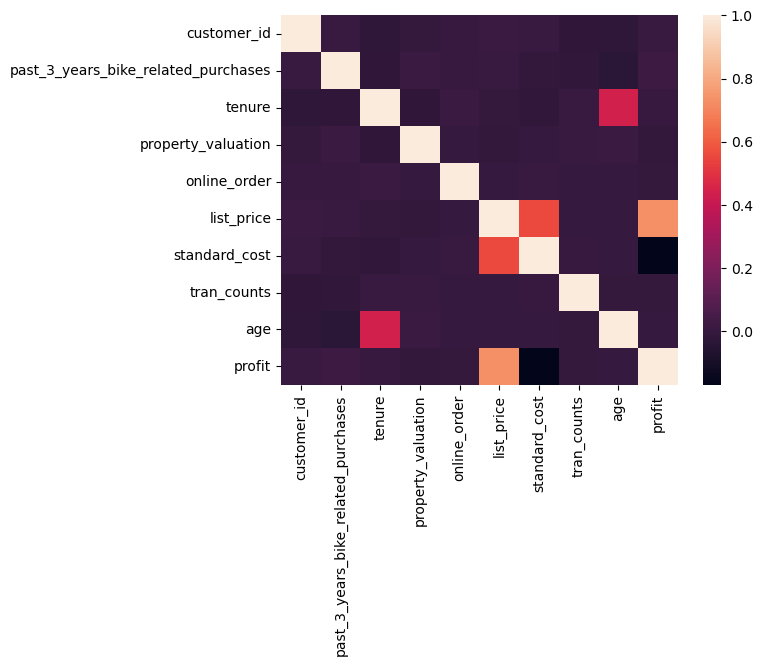

In [107]:
sb.heatmap(data=mer_df.corr())

In [78]:
new_cus=pd.read_excel('/Users/chungkaichou/PycharmProjects/pythonProject1/PortFolio/Forage/KPMG/Task1/KPMG_VI_New_raw_data_update_final.xlsx',sheet_name='NewCustomerList',header=1)

/var/folders/dr/05g6dmcd47v9mvnt25smv94h0000gn/T/ipykernel_53816/1487107367.py:1: FutureWarning: Inferring datetime64[ns] from data containing strings is deprecated and will be removed in a future version. To retain the old behavior explicitly pass Series(data, dtype=datetime64[ns])
  new_cus=pd.read_excel('/Users/chungkaichou/PycharmProjects/pythonProject1/PortFolio/Forage/KPMG/Task1/KPMG_VI_New_raw_data_update_final.xlsx',sheet_name='NewCustomerList',header=1)


In [79]:
new_cus.shape

(1000, 23)

In [80]:
new_cus.describe()

,past_3_years_bike_related_purchases,tenure,postcode,property_valuation,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Rank,Value
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,49.836000,11.388000,3019.227000,7.397000,0.747340,0.839005,0.942673,0.870514,498.819000,498.819000,0.881714
std,27.796686,5.037145,848.895767,2.758804,0.205082,0.248858,0.294832,0.280891,288.810997,288.810997,0.293525
min,0.000000,0.000000,2000.000000,1.000000,0.400000,0.400000,0.400000,0.340000,1.000000,1.000000,0.340000
25%,26.750000,7.000000,2209.000000,6.000000,0.570000,0.637500,0.712500,0.658750,250.000000,250.000000,0.649531
50%,51.000000,11.000000,2800.000000,8.000000,0.750000,0.820000,0.912500,0.842625,500.000000,500.000000,0.860000
75%,72.000000,15.000000,3845.500000,9.000000,0.920000,1.031875,1.142969,1.062500,750.250000,750.250000,1.075000
max,99.000000,22.000000,4879.000000,12.000000,1.100000,1.375000,1.718750,1.718750,1000.000000,1000.000000,1.718750


In [81]:
new_cus.dtypes

first_name                                     object
last_name                                      object
gender                                         object
past_3_years_bike_related_purchases             int64
DOB                                    datetime64[ns]
job_title                                      object
job_industry_category                          object
wealth_segment                                 object
deceased_indicator                             object
owns_car                                       object
tenure                                          int64
address                                        object
postcode                                        int64
state                                          object
country                                        object
property_valuation                              int64
Unnamed: 16                                   float64
Unnamed: 17                                   float64
Unnamed: 18                 

In [82]:
new_cus.isnull().sum()

first_name                               0
last_name                               29
gender                                   0
past_3_years_bike_related_purchases      0
DOB                                     17
job_title                              106
job_industry_category                  165
wealth_segment                           0
deceased_indicator                       0
owns_car                                 0
tenure                                   0
address                                  0
postcode                                 0
state                                    0
country                                  0
property_valuation                       0
Unnamed: 16                              0
Unnamed: 17                              0
Unnamed: 18                              0
Unnamed: 19                              0
Unnamed: 20                              0
Rank                                     0
Value                                    0
dtype: int6

In [83]:
new_cus.drop(columns=['Unnamed: 16','Unnamed: 17','Unnamed: 18','Unnamed: 19','Unnamed: 20'],inplace=True)

In [84]:
new_cus['country'].unique()

array(['Australia'], dtype=object)

In [85]:
new_cus.drop(columns=['country','address','postcode'],inplace=True)

In [86]:
new_cus['gender'].value_counts()

Female    513
Male      470
U          17
Name: gender, dtype: int64

In [87]:
new_cus['wealth_segment'].value_counts()

Mass Customer        508
High Net Worth       251
Affluent Customer    241
Name: wealth_segment, dtype: int64

In [88]:
new_cus['state'].value_counts()

NSW    506
VIC    266
QLD    228
Name: state, dtype: int64

In [89]:
new_cus['job_industry_category'].value_counts()

Financial Services    203
Manufacturing         199
Health                152
Retail                 78
Property               64
IT                     51
Entertainment          37
Argiculture            26
Telecommunications     25
Name: job_industry_category, dtype: int64

In [90]:
for i in mer_df.columns:
    print(i)

customer_id
gender
past_3_years_bike_related_purchases
job_industry_category
wealth_segment
deceased_indicator
owns_car
tenure
state
property_valuation
online_order
order_status
brand
product_line
product_class
product_size
list_price
standard_cost
tran_counts
age
profit


In [91]:
for i in new_cus.columns:
    print(i)

first_name
last_name
gender
past_3_years_bike_related_purchases
DOB
job_title
job_industry_category
wealth_segment
deceased_indicator
owns_car
tenure
state
property_valuation
Rank
Value


In [94]:
new_cus['age']=new_cus['DOB'].apply(tran_dob_age)
new_cus['age']=new_cus['age'].astype('<m8[Y]')

In [97]:
new_cus.drop(columns=['first_name','last_name','DOB','job_title'],inplace=True)

In [114]:
new_cus['age'].isnull().sum()

0

In [102]:
new_cus['age'].fillna(new_cus['age'].median(),inplace=True)

In [104]:
new_cus['job_industry_category'].fillna(new_cus['job_industry_category'].mode()[0],inplace=True)

In [105]:
new_cus['job_industry_category'].isnull().sum()

0

In [112]:
new_cus['age_group']=new_cus['age'].apply(age_grouping)

In [113]:
new_cus.head()

,gender,past_3_years_bike_related_purchases,job_industry_category,wealth_segment,deceased_indicator,owns_car,tenure,state,property_valuation,Rank,Value,age,age_group
0,Male,86,Manufacturing,Mass Customer,N,Yes,14,QLD,6,1,1.718750,66.0,Senior Adults
1,Male,69,Property,Mass Customer,N,No,16,NSW,11,1,1.718750,53.0,Adults
2,Female,10,Financial Services,Affluent Customer,N,No,10,VIC,5,1,1.718750,49.0,Adults
3,Female,64,Manufacturing,Affluent Customer,N,Yes,5,QLD,1,4,1.703125,44.0,Adults
4,Female,34,Financial Services,Affluent Customer,N,No,19,NSW,9,4,1.703125,58.0,Adults
